In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
with open("ai_jobs_market_2025_2026.csv", "r", encoding="utf-8") as file:
    csv = file.read()

print(csv)

job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NLP|Testing|Cloud,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|P

In [3]:
df = pd.read_csv('ai_jobs_market_2025_2026.csv')

In [4]:
df.isnull().sum()

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

In [5]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [6]:
df['annual_salary_usd'] = pd.to_numeric(df['annual_salary_usd'], errors='coerce')

In [7]:
df[(df['annual_salary_usd'] < df['salary_min_usd']) |
   (df['annual_salary_usd'] > df['salary_max_usd'])]

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)
20,AIJOB0021,Multimodal AI Engineer,AI Engineering,Senior (6-9 yrs),3,Bootcamp/Self-taught,329000.0,160000,300000,Chicago,...,12.7,90,27.5,9.0,2025,2,1,0,0,Elite (>$300k)
21,AIJOB0022,MLOps Engineer,ML Operations,Senior (6-9 yrs),9,Bachelor's,272000.0,130000,260000,Dubai,...,12.8,93,77.0,6.3,2026,3,1,0,0,Senior ($200-300k)
22,AIJOB0023,AI Business Analyst,Business,Lead (10+ yrs),7,Bootcamp/Self-taught,201000.0,95000,180000,Los Angeles,...,16.5,78,16.4,9.0,2026,3,1,0,0,Senior ($200-300k)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1481,AIJOB1482,AI Product Manager,Product,Lead (10+ yrs),4,PhD,294000.0,140000,260000,Remote,...,8.3,85,6.5,9.6,2026,3,1,1,0,Senior ($200-300k)
1485,AIJOB1486,Robotics Engineer (AI),Robotics,Mid (3-5 yrs),7,Bachelor's,254000.0,125000,240000,Boston,...,17.4,76,29.0,7.8,2026,2,0,1,0,Senior ($200-300k)
1487,AIJOB1488,RAG Engineer,AI Engineering,Lead (10+ yrs),6,Associate's,336000.0,145000,280000,Dubai,...,3.8,94,59.6,9.8,2026,3,1,1,1,Elite (>$300k)
1492,AIJOB1493,Prompt Engineer,AI Engineering,Senior (6-9 yrs),5,PhD,233000.0,90000,200000,Seattle,...,3.2,82,20.7,8.1,2026,2,1,1,1,Senior ($200-300k)


In [8]:
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

In [10]:
df.describe()

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,6.216000,194892.000000,135448.666667,257537.333333,10.858200,87.523333,31.116333,7.897333,2025.584000,3.968000,0.496667,0.754000,0.218000
std,2.675216,66506.822013,24448.950878,39852.822207,4.029742,8.026315,22.046343,1.102846,0.493058,3.270388,0.500156,0.430822,0.413025
min,1.000000,90000.000000,90000.000000,180000.000000,3.000000,68.000000,5.000000,6.000000,2025.000000,1.000000,0.000000,0.000000,0.000000
25%,4.000000,144750.000000,120000.000000,218000.000000,8.200000,82.000000,15.375000,6.900000,2025.000000,2.000000,0.000000,1.000000,0.000000
50%,6.000000,180000.000000,140000.000000,270000.000000,10.500000,89.000000,23.400000,7.900000,2026.000000,3.000000,0.000000,1.000000,0.000000
75%,8.000000,236250.000000,155000.000000,290000.000000,14.200000,95.000000,42.700000,8.900000,2026.000000,5.000000,1.000000,1.000000,0.000000
max,15.000000,384000.000000,180000.000000,320000.000000,18.000000,98.000000,87.800000,9.800000,2026.000000,12.000000,1.000000,1.000000,1.000000


<Axes: >

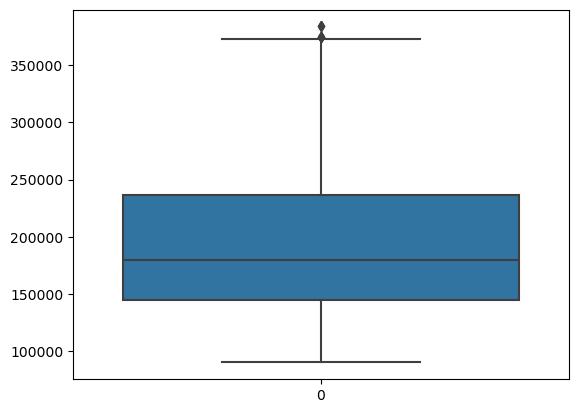

In [11]:
sns.boxplot(df['annual_salary_usd'])

In [12]:
df['experience_level'].unique()

array(['Senior (6-9 yrs)', 'Lead (10+ yrs)', 'Entry (0-2 yrs)',
       'Mid (3-5 yrs)'], dtype=object)

In [13]:
df[['is_senior','is_remote_friendly','is_llm_role']] = df[['is_senior','is_remote_friendly','is_llm_role']].astype(int)

In [14]:
df.drop(columns=['job_id'], inplace=True)

In [15]:
df['salary_range'] = df['salary_max_usd'] - df['salary_min_usd']

In [16]:
df.head()

,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,...,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier,salary_range
0,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,...,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k),135000
1,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,...,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k),110000
2,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,...,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k),140000
3,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,...,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k),90000
4,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,...,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k),120000


In [17]:
city_salary = df.groupby('city')['annual_salary_usd'].mean().sort_values(ascending=False)

print(city_salary)

city
New York         248659.701493
San Francisco    240521.739130
Seattle          230544.927536
Remote           222043.902439
Chicago          219511.688312
Boston           219400.000000
Los Angeles      216184.126984
Austin           206649.350649
Dubai            194225.806452
Zurich           190592.105263
Sydney           188000.000000
Paris            183151.515152
Singapore        181830.985915
Berlin           181180.246914
London           180644.444444
Toronto          180588.235294
Amsterdam        175256.756757
Tokyo            170131.578947
Beijing          134287.356322
Bangalore        133122.807018
Name: annual_salary_usd, dtype: float64


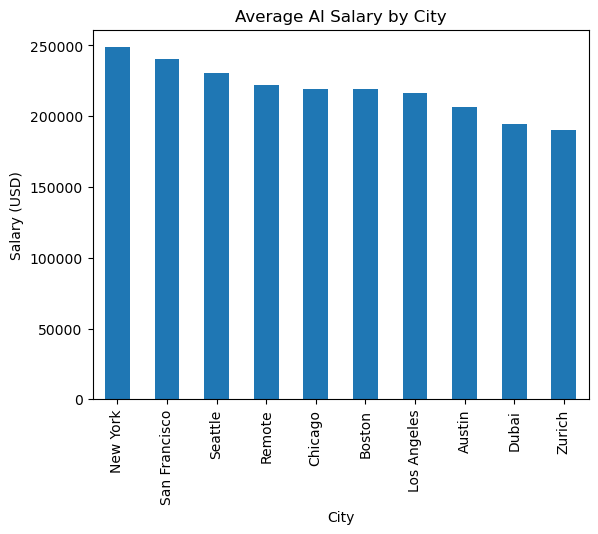

In [18]:
city_salary.head(10).plot(kind='bar')
plt.title("Average AI Salary by City")
plt.ylabel("Salary (USD)")
plt.xlabel("City")
plt.show()

In [19]:
exp_salary = df.groupby('experience_level')['annual_salary_usd'].mean()

print(exp_salary)

experience_level
Entry (0-2 yrs)     150038.961039
Lead (10+ yrs)      240055.118110
Mid (3-5 yrs)       175983.783784
Senior (6-9 yrs)    214280.219780
Name: annual_salary_usd, dtype: float64


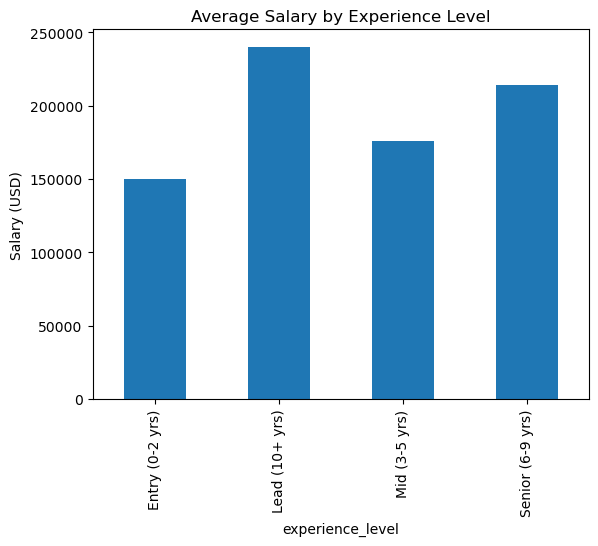

In [20]:
exp_salary.plot(kind='bar')
plt.title("Average Salary by Experience Level")
plt.ylabel("Salary (USD)")
plt.show()

In [21]:
growth = df.groupby('job_category')['demand_growth_yoy_pct'].mean().sort_values(ascending=False)

print(growth)

job_category
ML Operations       52.819608
AI Engineering      40.247826
Data Science        31.503937
Data Engineering    19.652941
Infrastructure      18.398182
Robotics            18.067568
Architecture        18.032692
Research            17.478000
Product             17.311429
Security            17.150000
Business            17.116129
Governance          16.918033
Name: demand_growth_yoy_pct, dtype: float64


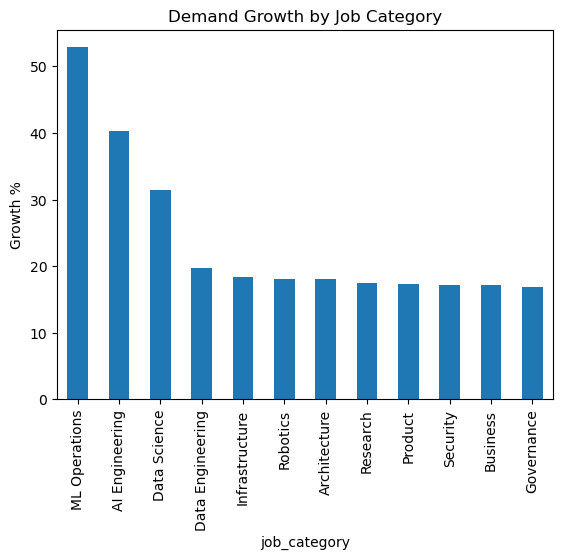

In [22]:
growth.plot(kind='bar')
plt.title("Demand Growth by Job Category")
plt.ylabel("Growth %")
plt.show()

In [23]:
llm_salary = df.groupby('is_llm_role')['annual_salary_usd'].mean()

print(llm_salary)

is_llm_role
0    191308.610401
1    207746.177370
Name: annual_salary_usd, dtype: float64


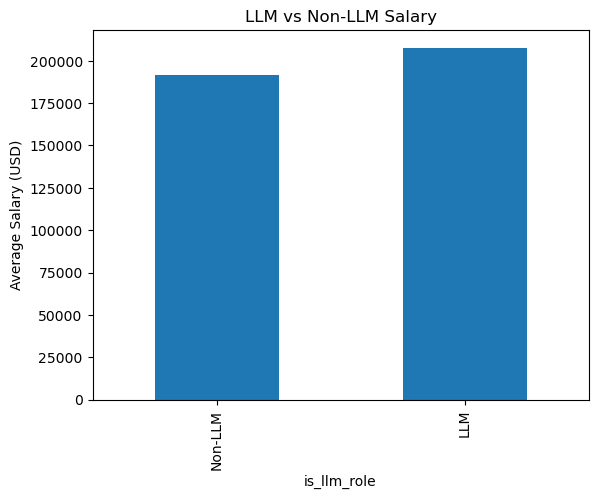

In [24]:
llm_salary.plot(kind='bar')
plt.title("LLM vs Non-LLM Salary")
plt.ylabel("Average Salary (USD)")
plt.xticks([0,1],["Non-LLM","LLM"])
plt.show()

In [25]:
remote_jobs = df['is_remote_friendly'].value_counts()

print(remote_jobs)

is_remote_friendly
1    1131
0     369
Name: count, dtype: int64


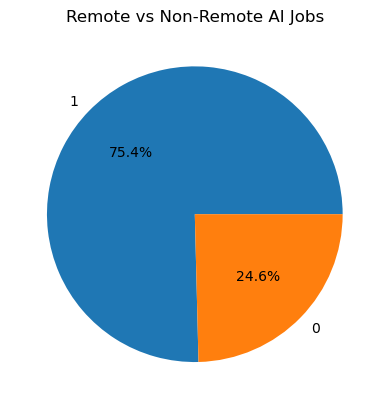

In [26]:
remote_jobs.plot(kind='pie', autopct='%1.1f%%')
plt.title("Remote vs Non-Remote AI Jobs")
plt.ylabel("")
plt.show()

In [27]:
top_jobs = df.groupby('job_title')['annual_salary_usd'].mean().sort_values(ascending=False)
print(top_jobs.head(10))

job_title
AI Solutions Architect      251576.923077
Senior ML Engineer          247953.125000
LLM Engineer                240960.000000
AI Agent Developer          225649.122807
Multimodal AI Engineer      221791.044776
RAG Engineer                218226.415094
NLP Engineer                210854.545455
Computer Vision Engineer    209173.913043
Generative AI Engineer      206760.563380
Deep Learning Engineer      203810.344828
Name: annual_salary_usd, dtype: float64


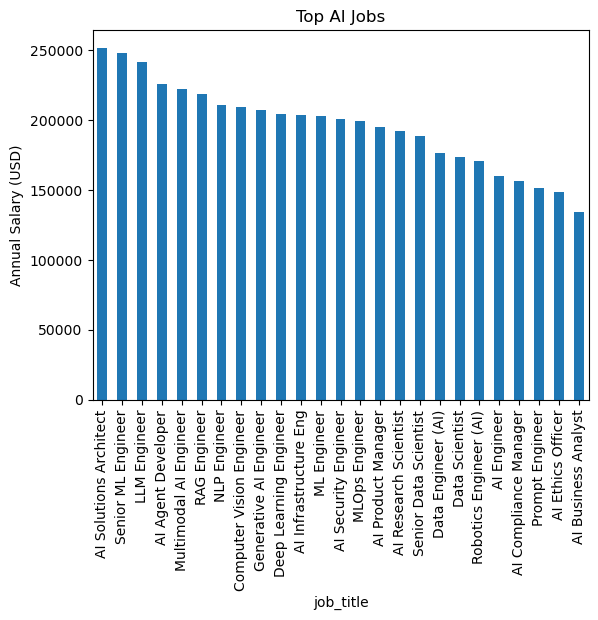

In [28]:
top_jobs.plot(kind='bar')
plt.title("Top AI Jobs")
plt.ylabel("Annual Salary (USD)")
plt.show()

In [29]:
df['years_of_experience'].dtype

dtype('int64')

In [30]:
df['years_of_experience'].unique()

array([ 7,  2,  4,  3,  5,  1,  8, 15,  6,  9, 10, 11, 12, 13, 14])

In [31]:
df['years_of_experience'] = pd.to_numeric(df['years_of_experience'], errors='coerce')

In [32]:
df['years_of_experience'].fillna(df['years_of_experience'].median(), inplace=True)

In [33]:
df['years_of_experience'].dtype
df['years_of_experience'].describe()

count    1500.000000
mean        6.216000
std         2.675216
min         1.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        15.000000
Name: years_of_experience, dtype: float64

In [35]:
corr = df.corr(numeric_only=True)

In [36]:
mask = np.triu(np.ones_like(corr, dtype=bool))

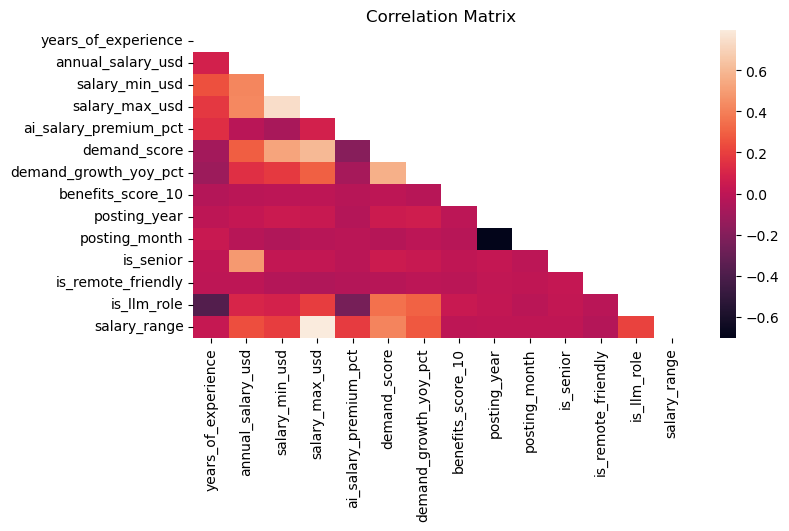

In [74]:
plt.figure(figsize=(8,4))
sns.heatmap(corr, mask=mask, annot=False, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [40]:
X = df.drop('annual_salary_usd', axis=1)
y = df['annual_salary_usd']

In [41]:
X = pd.get_dummies(X)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [43]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [44]:
pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, pred))

MAE: 10839.213333333333


In [45]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

salary_tier_Elite (>$300k)           0.449915
salary_tier_Senior ($200-300k)       0.394326
salary_tier_Upper-Mid ($150-200k)    0.063728
salary_min_usd                       0.009557
demand_growth_yoy_pct                0.006952
salary_tier_Entry (<$100k)           0.005645
ai_salary_premium_pct                0.005030
salary_tier_Mid ($100-150k)          0.004517
salary_max_usd                       0.004328
benefits_score_10                    0.004223
dtype: float64

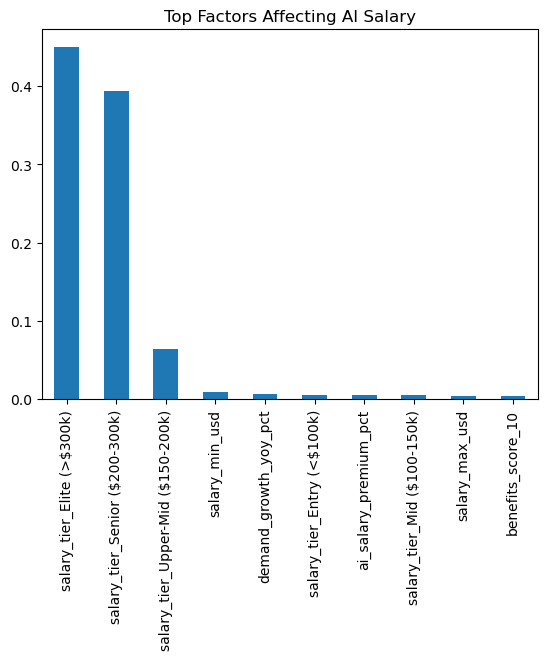

In [46]:
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Factors Affecting AI Salary")
plt.show()

In [47]:
from sklearn.cluster import KMeans
features = df[['years_of_experience','annual_salary_usd','demand_score']]
kmeans = KMeans(n_clusters=4)
df['cluster'] = kmeans.fit_predict(features)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


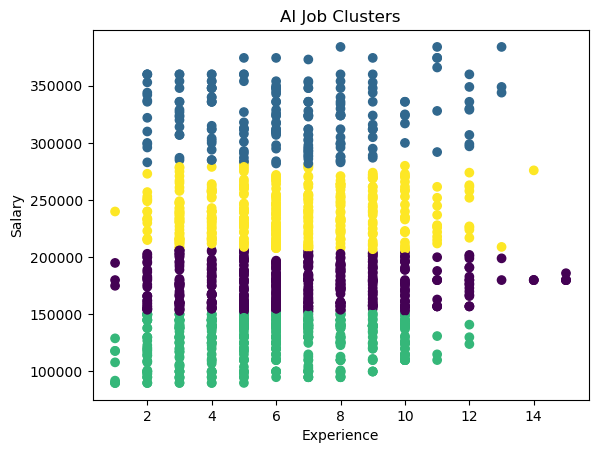

In [48]:
plt.scatter(df['years_of_experience'], df['annual_salary_usd'], c=df['cluster'])
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("AI Job Clusters")
plt.show()

In [49]:
df.groupby('posting_year')['annual_salary_usd'].mean()

posting_year
2025    193140.705128
2026    196139.497717
Name: annual_salary_usd, dtype: float64

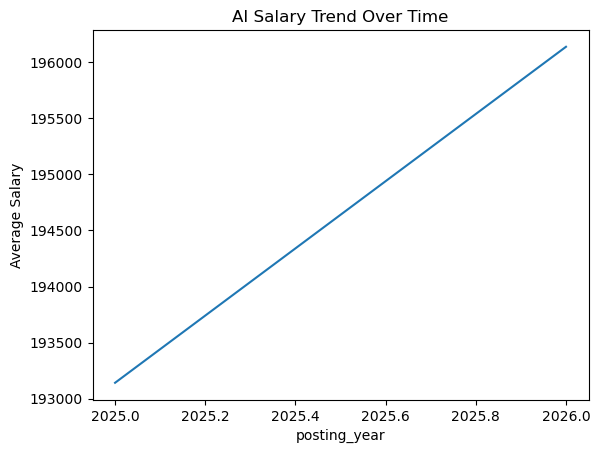

In [50]:
df.groupby('posting_year')['annual_salary_usd'].mean().plot()
plt.title("AI Salary Trend Over Time")
plt.ylabel("Average Salary")
plt.show()

In [51]:
df.groupby('is_remote_friendly')['annual_salary_usd'].mean()

is_remote_friendly
0    195268.834688
1    194769.053935
Name: annual_salary_usd, dtype: float64

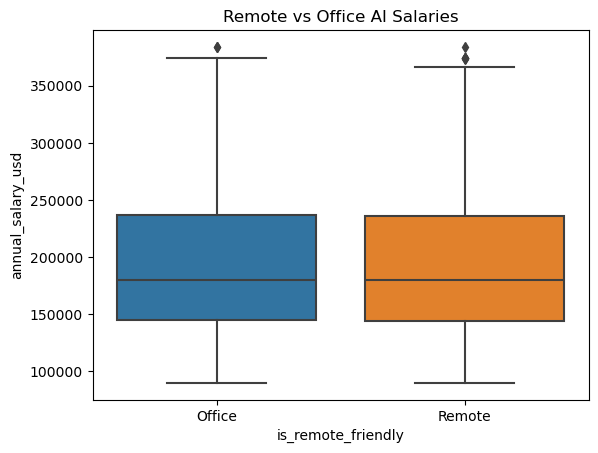

In [52]:
sns.boxplot(x='is_remote_friendly', y='annual_salary_usd', data=df)
plt.xticks([0,1],["Office","Remote"])
plt.title("Remote vs Office AI Salaries")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


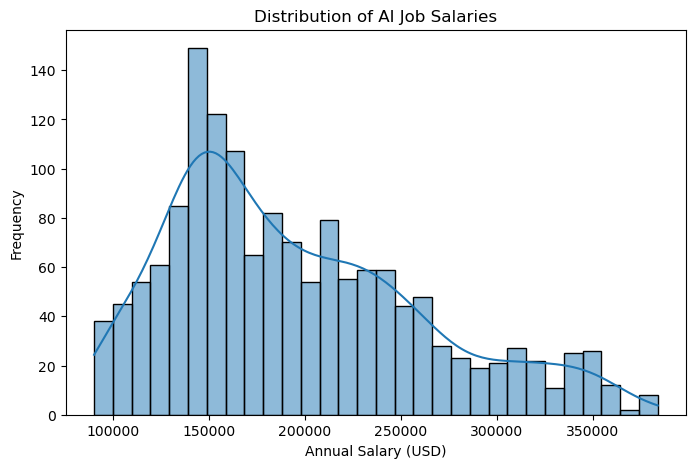

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df['annual_salary_usd'], bins=30, kde=True)
plt.title("Distribution of AI Job Salaries")
plt.xlabel("Annual Salary (USD)")
plt.ylabel("Frequency")
plt.show()

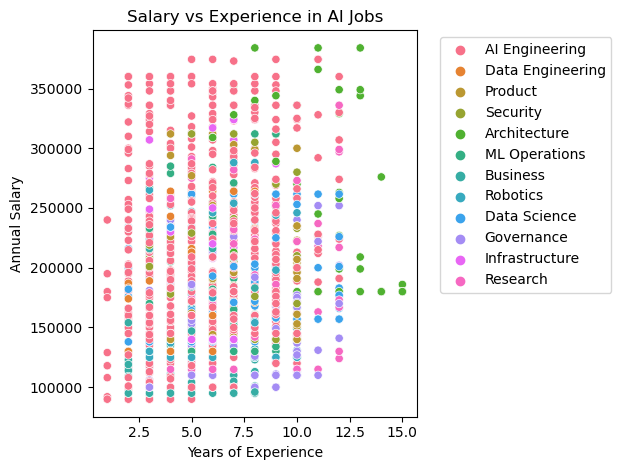

In [54]:
sns.scatterplot(
    x='years_of_experience',
    y='annual_salary_usd',
    data=df,
    hue='job_category'
)
plt.title("Salary vs Experience in AI Jobs")
plt.xlabel("Years of Experience")
plt.ylabel("Annual Salary")
# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

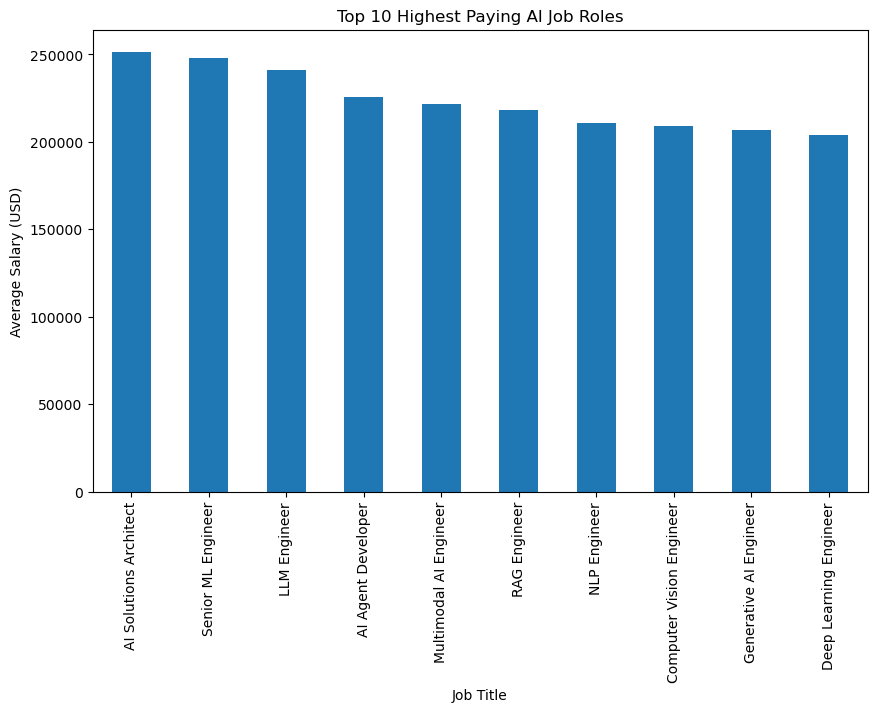

In [55]:
top_jobs = df.groupby('job_title')['annual_salary_usd'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top_jobs.plot(kind='bar')
plt.title("Top 10 Highest Paying AI Job Roles")
plt.ylabel("Average Salary (USD)")
plt.xlabel("Job Title")
plt.show()

In [57]:
pivot = df.pivot_table(
    values='annual_salary_usd',
    index='experience_level',
    columns='job_category',
    aggfunc='mean'
)

In [72]:
pivot

job_category,AI Engineering,Architecture,Business,Data Engineering,Data Science,Governance,Infrastructure,ML Operations,Product,Research,Robotics,Security
experience_level,,,,,,,,,,,,
Entry (0-2 yrs),155273.224044,194100.0,101047.619048,139235.294118,158172.413793,124090.909091,170375.000000,143800.000000,158100.000000,149181.818182,136190.476190,152750.000000
Mid (3-5 yrs),187787.356322,246750.0,121562.500000,168375.000000,157774.193548,126133.333333,179388.888889,177875.000000,172923.076923,183384.615385,162300.000000,187263.157895
Senior (6-9 yrs),232755.675676,290125.0,153153.846154,195230.769231,189388.235294,170382.352941,205533.333333,218214.285714,186266.666667,215083.333333,203062.500000,218800.000000
Lead (10+ yrs),252191.752577,326500.0,188250.000000,210153.846154,215296.969697,197400.000000,251357.142857,256454.545455,246181.818182,214857.142857,193411.764706,252500.000000


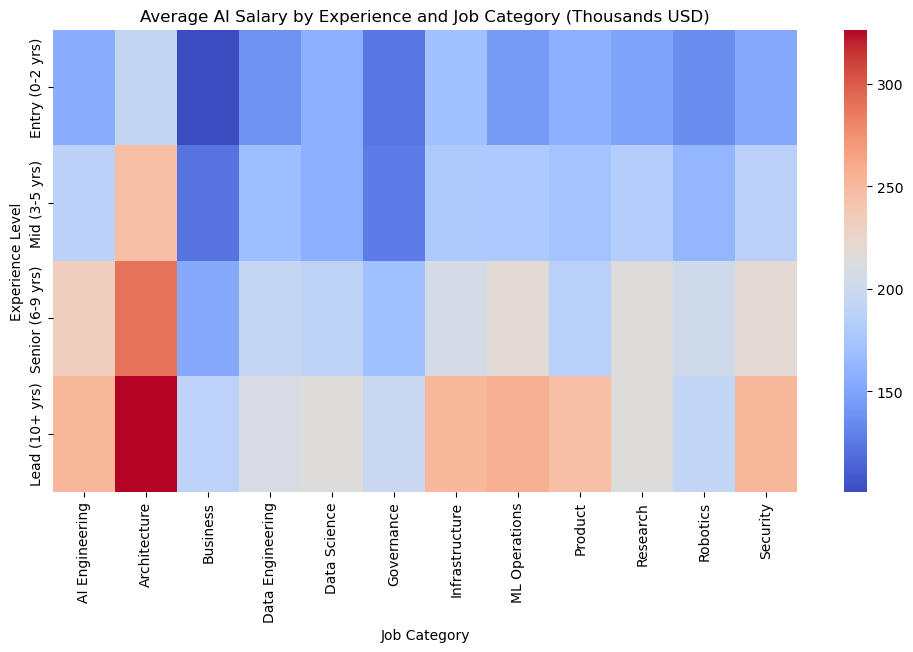

In [73]:
plt.figure(figsize=(12,6))
sns.heatmap(pivot/1000, annot=False, fmt=".0f", cmap="coolwarm")

plt.title("Average AI Salary by Experience and Job Category (Thousands USD)")
plt.xlabel("Job Category")
plt.ylabel("Experience Level")
plt.show()

In [64]:
from sklearn.ensemble import GradientBoostingRegressor

In [65]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

GradientBoostingRegressor()

In [66]:
y_pred = model.predict(X_test)

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [68]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 11666.170984924953
MSE: 238826680.5958678
R2 Score: 0.9449366190949132


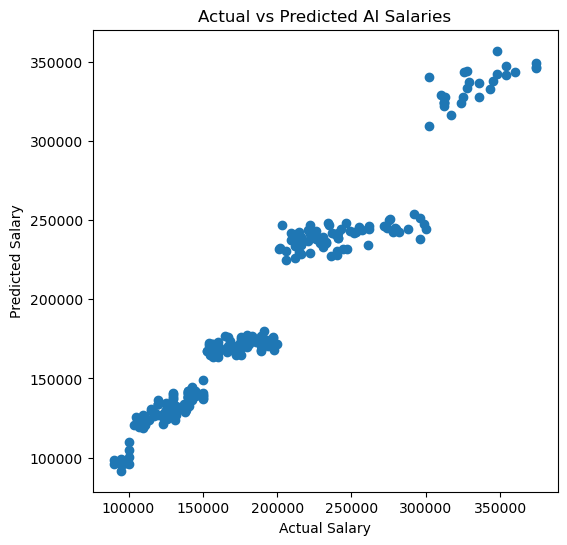

In [69]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted AI Salaries")
plt.show()